In [1]:
#imports
import numpy as np
import matplotlib.pyplot as plt
import re

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

from tensorflow.keras.utils import to_categorical

In [2]:
#load text corpus
corpus = """
Artificial Intelligence is transforming the world.
Machine learning helps computers learn from data.
Deep learning is a branch of machine learning.
Neural networks are inspired by the human brain.
Artificial Intelligence is used in healthcare, education,
banking, robotics, agriculture and transportation.
Deep learning models are capable of learning complex patterns.
Natural language processing enables machines to understand language.
Text generation is an interesting application of deep learning.
"""

In [3]:
#clean text
corpus = corpus.lower()

corpus = re.sub(r'[^a-zA-Z\s]', '', corpus)

corpus = re.sub(r'\s+', ' ', corpus).strip()

print(corpus)

artificial intelligence is transforming the world machine learning helps computers learn from data deep learning is a branch of machine learning neural networks are inspired by the human brain artificial intelligence is used in healthcare education banking robotics agriculture and transportation deep learning models are capable of learning complex patterns natural language processing enables machines to understand language text generation is an interesting application of deep learning


In [4]:
#tokenization
tokenizer = Tokenizer()

tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Total Words:", total_words)

Total Words: 50


In [5]:
#Buil dn-gram sequences
input_sequences = []

for line in corpus.split("."):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):

        n_gram = token_list[:i+1]

        input_sequences.append(n_gram)

print(input_sequences[:5])

[[5, 6], [5, 6, 2], [5, 6, 2, 11], [5, 6, 2, 11, 7], [5, 6, 2, 11, 7, 12]]


In [6]:
#padding
max_sequence_len = max(len(seq) for seq in input_sequences)

input_sequences = np.array(
    pad_sequences(
        input_sequences,
        maxlen=max_sequence_len,
        padding='pre'
    )
)

print(input_sequences.shape)

(66, 67)


In [7]:
#split X and Y
X = input_sequences[:, :-1]

y = input_sequences[:, -1]

print(X.shape)

print(y.shape)

(66, 66)
(66,)


In [8]:
#One hot encode y
y = to_categorical(y, num_classes=total_words)

print(y.shape)

(66, 50)


In [9]:
#simple RNN
rnn_model = Sequential()

rnn_model.add(
    Embedding(
        input_dim=total_words,
        output_dim=128,
        input_length=max_sequence_len-1
    )
)

rnn_model.add(SimpleRNN(128))

rnn_model.add(Dense(total_words, activation='softmax'))

rnn_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
#LSTM model
lstm_model = Sequential()

lstm_model.add(
    Embedding(
        total_words,
        128,
        input_length=max_sequence_len-1
    )
)

lstm_model.add(LSTM(128))

lstm_model.add(Dense(total_words, activation='softmax'))

lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
#GRU model
gru_model = Sequential()

gru_model.add(
    Embedding(
        total_words,
        128,
        input_length=max_sequence_len-1
    )
)

gru_model.add(GRU(128))

gru_model.add(Dense(total_words, activation='softmax'))

gru_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
#train all
rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 517ms/step - accuracy: 0.0455 - loss: 3.9420
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1818 - loss: 3.7277
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2576 - loss: 3.6568
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2879 - loss: 3.5821
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3333 - loss: 3.4554
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3485 - loss: 3.3730
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4697 - loss: 3.2855
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4697 - loss: 3.2207
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4697 - loss: 3.1604
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5152 - loss: 3.0391
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5758 - loss: 2.9566
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6515 - l

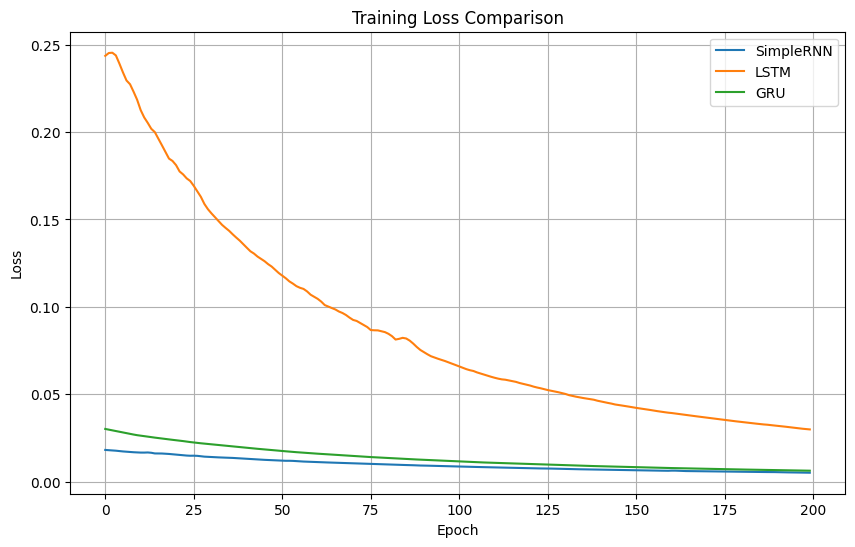

In [14]:
#plot
plt.figure(figsize=(10,6))

plt.plot(
    rnn_history.history['loss'],
    label='SimpleRNN'
)

plt.plot(
    lstm_history.history['loss'],
    label='LSTM'
)

plt.plot(
    gru_history.history['loss'],
    label='GRU'
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss Comparison")

plt.legend()

plt.grid(True)

plt.show()

In [15]:
#Generate sequence
def generate_text(model, seed_text, next_words):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len-1,
            padding='pre'
        )

        predicted = model.predict(token_list, verbose=0)

        predicted_index = np.argmax(predicted)

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted_index:

                output_word = word

                break

        seed_text += " " + output_word

    return seed_text

In [16]:
#generate 10 words
seed = "artificial intelligence"

print("SimpleRNN")
print(generate_text(rnn_model, seed, 10))

print()

print("LSTM")
print(generate_text(lstm_model, seed, 10))

print()

print("GRU")
print(generate_text(gru_model, seed, 10))

SimpleRNN
artificial intelligence is transforming the world machine learning helps computers learn from

LSTM
artificial intelligence is transforming the world machine learning helps computers learn from

GRU
artificial intelligence is transforming the world machine learning helps computers learn from


In [17]:
#custom corpus
corpus = """
Artificial Intelligence is transforming the world.
Machine learning helps computers learn from data.
Deep learning is a branch of machine learning.
Neural networks are inspired by the human brain.
Artificial Intelligence is used in healthcare, education,
banking, robotics, agriculture and transportation.
Deep learning models are capable of learning complex patterns.
Natural language processing enables machines to understand language.
Text generation is an interesting application of deep learning.
"""

In [18]:
#increased embedding dimensions
Embedding(
    input_dim=total_words,
    output_dim=128,
    input_length=max_sequence_len-1
)

<Embedding name=embedding_3, built=False>

In [20]:
#hidden units increase
SimpleRNN(128)

LSTM(128)

GRU(128)

<GRU name=gru_1, built=False>

In [21]:
#generate 10 words
generate_text(rnn_model, seed, 10)

generate_text(lstm_model, seed, 10)

generate_text(gru_model, seed, 10)

'artificial intelligence is transforming the world machine learning helps computers learn from'